In [1]:
import pandas as pd
import numpy as np
import os

# ==========================================
# CONFIGURATION: Update this to your local path
# ==========================================
DATA_DIR = r"D:\SSE\carbon aware thermostat" 
# ==========================================

def calculate_metrics_updated(base_path):
    # Mapping the new filenames to descriptive labels
    target_files = {
        "Bang-Bang (Cold)": "room_data_bang_c.csv",
        "Standard MPC (Cold)": "room_data_mpc_c_0.csv",
        "Carbon-Aware MPC (Cold)": "room_data_mpc_c_6.csv",
        "Bang-Bang (Warm)": "room_data_bang_w.csv",
        "Standard MPC (Warm)": "room_data_mpc_w_0.csv",
        "Carbon-Aware MPC (Warm)": "room_data_mpc_w_6.csv"
    }
    
    results = []

    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        if not os.path.exists(file_path): continue
        
        df = pd.read_csv(file_path)
        
        # 1. Carbon Correlation (r)
        # We use a 1-hour rolling window to capture the strategy trend
        avg_dt = df['dt'].mean()
        window = int(3600 / avg_dt)
        
        rolled_wattage = df['heating_wattage_W'].rolling(window=window).mean()
        rolled_intensity = df['carbon_intensity_gco2_per_kj'].rolling(window=window).mean()
        corr = rolled_wattage.corr(rolled_intensity)
        
        # 2. Low Carbon Heating %
        median_ci = df['carbon_intensity_gco2_per_kj'].median()
        low_ci_mask = df['carbon_intensity_gco2_per_kj'] <= median_ci
        low_ci_energy = (df[low_ci_mask]['heating_wattage_W'] * df[low_ci_mask]['dt']).sum()
        total_energy = (df['heating_wattage_W'] * df['dt']).sum()
        low_ci_ratio = (low_ci_energy / total_energy) * 100

        results.append({
            "Controller Scenario": label,
            "Carbon_Corr (r)": round(corr, 4),
            "Low_Carbon_Energy_%": f"{round(low_ci_ratio, 1)}%"
        })
            
    metrics_df = pd.DataFrame(results)
    print("\n--- UPDATED LOAD SHIFTING EFFICIENCY ---")
    print(metrics_df.to_string(index=False))
    metrics_df.to_csv(os.path.join(base_path, "updated_carbon_metrics.csv"), index=False)

calculate_metrics_updated(DATA_DIR)


--- UPDATED LOAD SHIFTING EFFICIENCY ---
    Controller Scenario  Carbon_Corr (r) Low_Carbon_Energy_%
       Bang-Bang (Cold)           0.3860               34.3%
    Standard MPC (Cold)           0.3556               33.5%
Carbon-Aware MPC (Cold)           0.3216               34.9%
       Bang-Bang (Warm)           0.3392               36.8%
    Standard MPC (Warm)           0.3151               36.4%
Carbon-Aware MPC (Warm)           0.2863               37.4%


C:\Users\prana\AppData\Local\Temp\ipykernel_25528\669047564.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Controller', y='room_temprature', data=full_df, palette="viridis", inner="quartile")


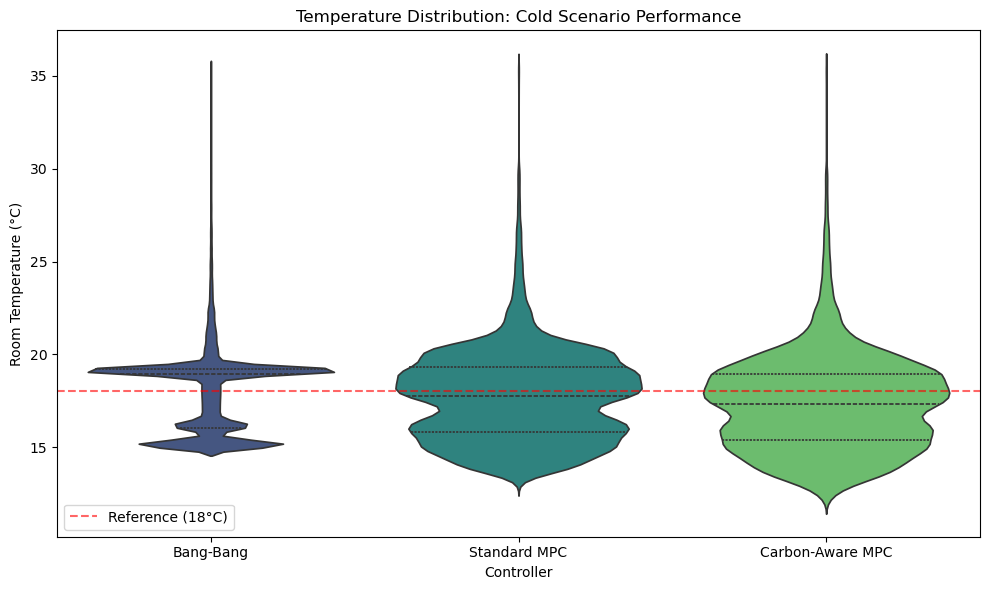

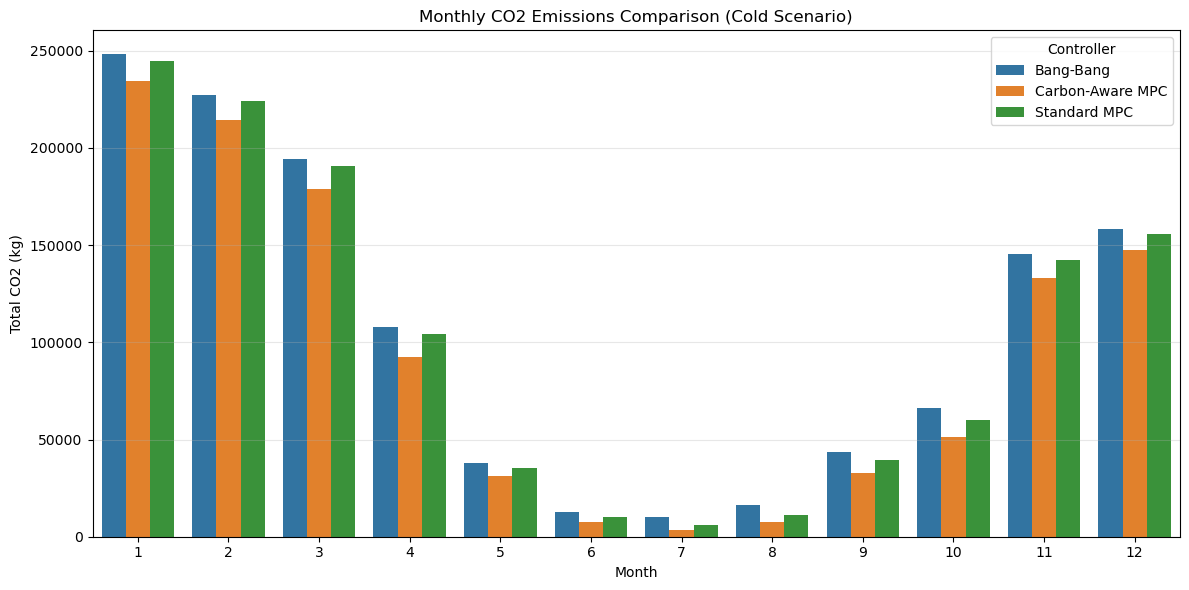

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_final_analysis_updated(base_path):
    target_files = {
        "Bang-Bang": "room_data_bang_c.csv",
        "Standard MPC": "room_data_mpc_c_0.csv",
        "Carbon-Aware MPC": "room_data_mpc_c_6.csv"
    }
    
    all_data = []
    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        if not os.path.exists(file_path): continue
        
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['Month'] = df['timestamp'].dt.month
        df['Controller'] = label
        
        # CO2 (kg): (W * dt) / 1000 = kJ. kJ * g/kJ = g. g / 1000 = kg.
        df['co2_kg'] = (df['heating_wattage_W'] * df['dt'] * df['carbon_intensity_gco2_per_kj']) / 1_000_000
        all_data.append(df)

    full_df = pd.concat(all_data)

    # Plot 1: Temperature Violin Plot (Cold Scenario)
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Controller', y='room_temprature', data=full_df, palette="viridis", inner="quartile")
    plt.axhline(18, color='red', linestyle='--', alpha=0.6, label='Reference (18°C)')
    plt.title("Temperature Distribution: Cold Scenario Performance")
    plt.ylabel("Room Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "violin_dist_updated.png"))

    # Plot 2: Monthly CO2 Comparison
    monthly_agg = full_df.groupby(['Month', 'Controller'])['co2_kg'].sum().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Month', y='co2_kg', hue='Controller', data=monthly_agg)
    plt.title("Monthly CO2 Emissions Comparison (Cold Scenario)")
    plt.ylabel("Total CO2 (kg)")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "monthly_comparison_updated.png"))

plot_final_analysis_updated(DATA_DIR)


In [11]:
import pandas as pd
import os

def calculate_thermostat_metrics(file_path):
    """Calculates MAE, Total Energy, CO2, and Estimated UA for a simulation file."""
    df = pd.read_csv(file_path)
    
    # 1. Mean Absolute Error (MAE) - How well it tracks the target
    mae = (df['room_temprature'] - df['preferred_room_temperature_C']).abs().mean()
    
    # 2. Total Energy (kJ) - Sum of Q_thermo (Joules) converted to kJ
    total_energy_kj = df['Q_thermo'].sum() / 1000
    
    # 3. Total CO2 (kg) - Sum of (Energy kJ * Intensity g/kJ) converted to kg
    total_co2_kg = ((df['Q_thermo'] / 1000) * df['carbon_intensity_gco2_per_kj']).sum() / 1000
    
    # 4. Estimated UA (W/K) - Thermal Transmittance Coefficient
    # Based on steady-state heat loss: Q = UA * (T_room - T_outside) * dt
    temp_diff = df['room_temprature'] - df['outside_temperature_C']
    ua_estimated = df['Q_thermo'].sum() / (temp_diff * df['dt']).sum()
    
    return {
        "File": os.path.basename(file_path),
        "MAE_degC": round(mae, 4),
        "Estimated_UA": round(ua_estimated, 2),
        "Total_Energy_kJ": round(total_energy_kj, 2),
        "Total_CO2_kg": round(total_co2_kg, 2)
    }


data_directory = r"D:\SSE\carbon aware thermostat"

file_names = [
    'room_data_bang_c.csv', 'room_data_bang_w.csv',
    'room_data_mpc_c_0.csv', 'room_data_mpc_c_6.csv',
    'room_data_mpc_w_0.csv', 'room_data_mpc_w_6.csv'
]

# Run the analysis
all_results = []
for name in file_names:
    full_path = os.path.join(data_directory, name)
    if os.path.exists(full_path):
        all_results.append(calculate_thermostat_metrics(full_path))
    else:
        print(f"File not found: {name}")

# Create DataFrame and display
summary_df = pd.DataFrame(all_results)
print("\n--- Carbon Aware Thermostat Analysis Summary ---")
print(summary_df)

# Optional: Save result to a CSV in the same folder
# summary_df.to_csv(os.path.join(data_directory, "final_results_calculated.csv"), index=False)


--- Carbon Aware Thermostat Analysis Summary ---
                    File  MAE_degC  Estimated_UA  Total_Energy_kJ  \
0   room_data_bang_c.csv    1.0186         23.96        4934340.0   
1   room_data_bang_w.csv    0.9243         23.96        5842350.0   
2  room_data_mpc_c_0.csv    1.3141         23.96        4725000.0   
3  room_data_mpc_c_6.csv    1.4009         23.96        4428000.0   
4  room_data_mpc_w_0.csv    1.1878         23.96        5589675.0   
5  room_data_mpc_w_6.csv    1.2646         23.96        5302800.0   

   Total_CO2_kg  
0    1268142.51  
1    1456850.27  
2    1224722.47  
3    1134583.39  
4    1403822.03  
5    1317862.99  


Success: Saved plot to D:\SSE\carbon aware thermostat\deep_dive_bang_vs_mpc.png


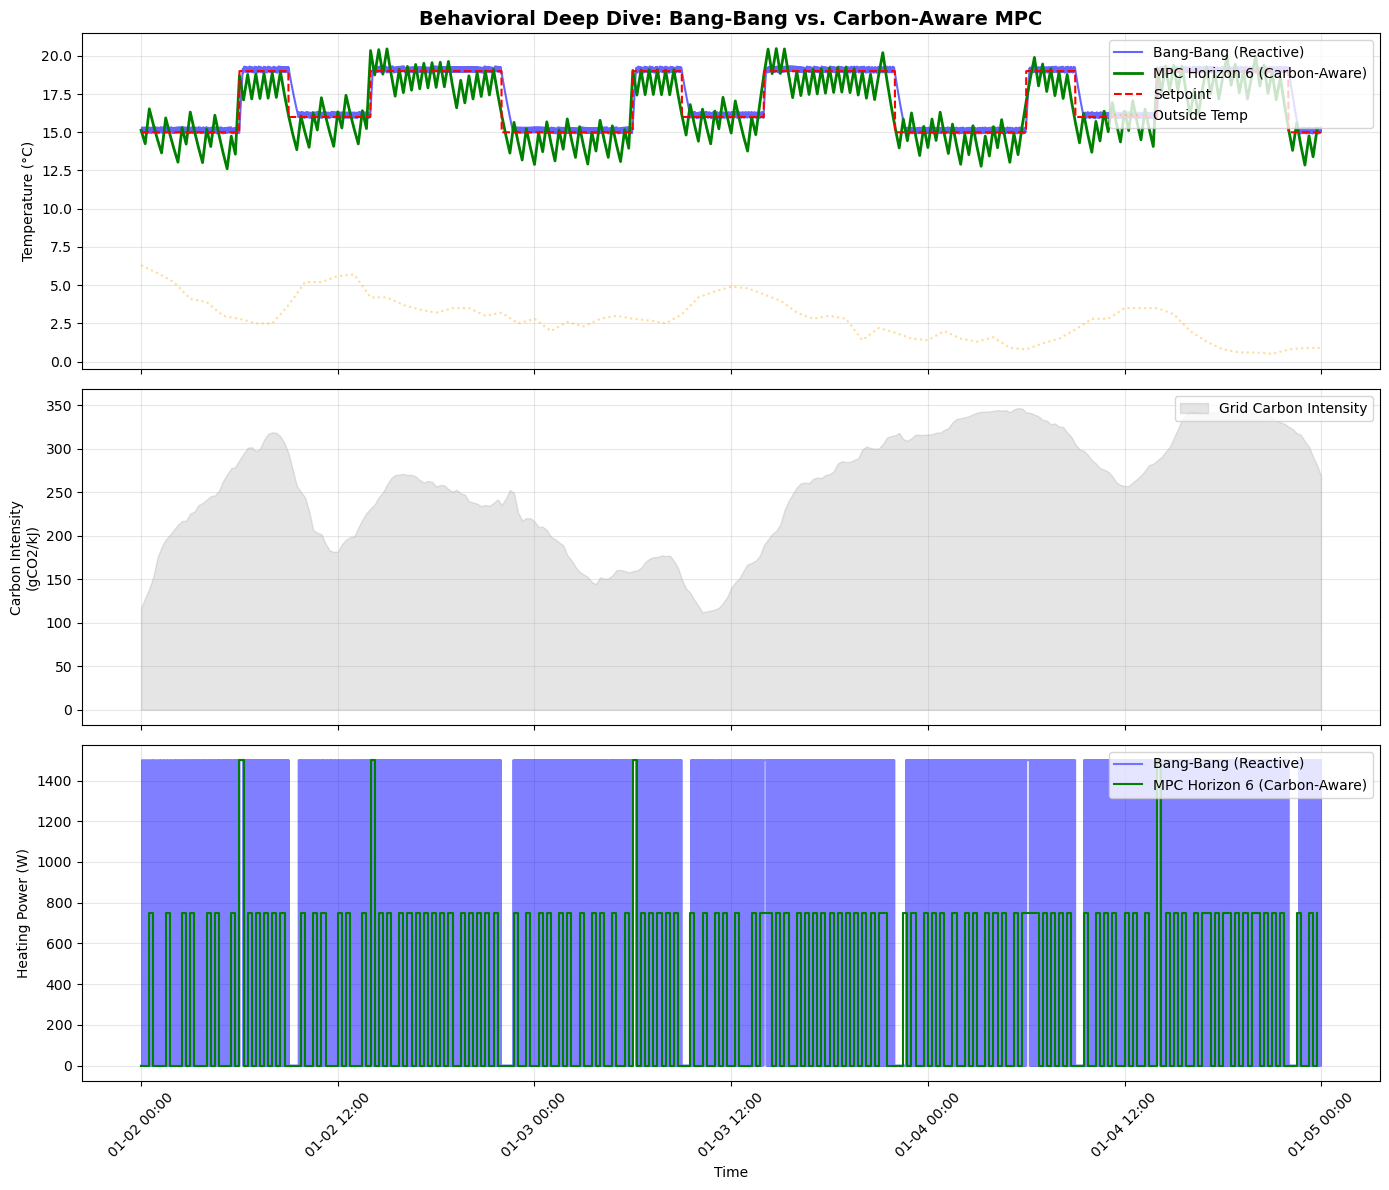

Success: Saved plot to D:\SSE\carbon aware thermostat\deep_dive_horizon_impact.png


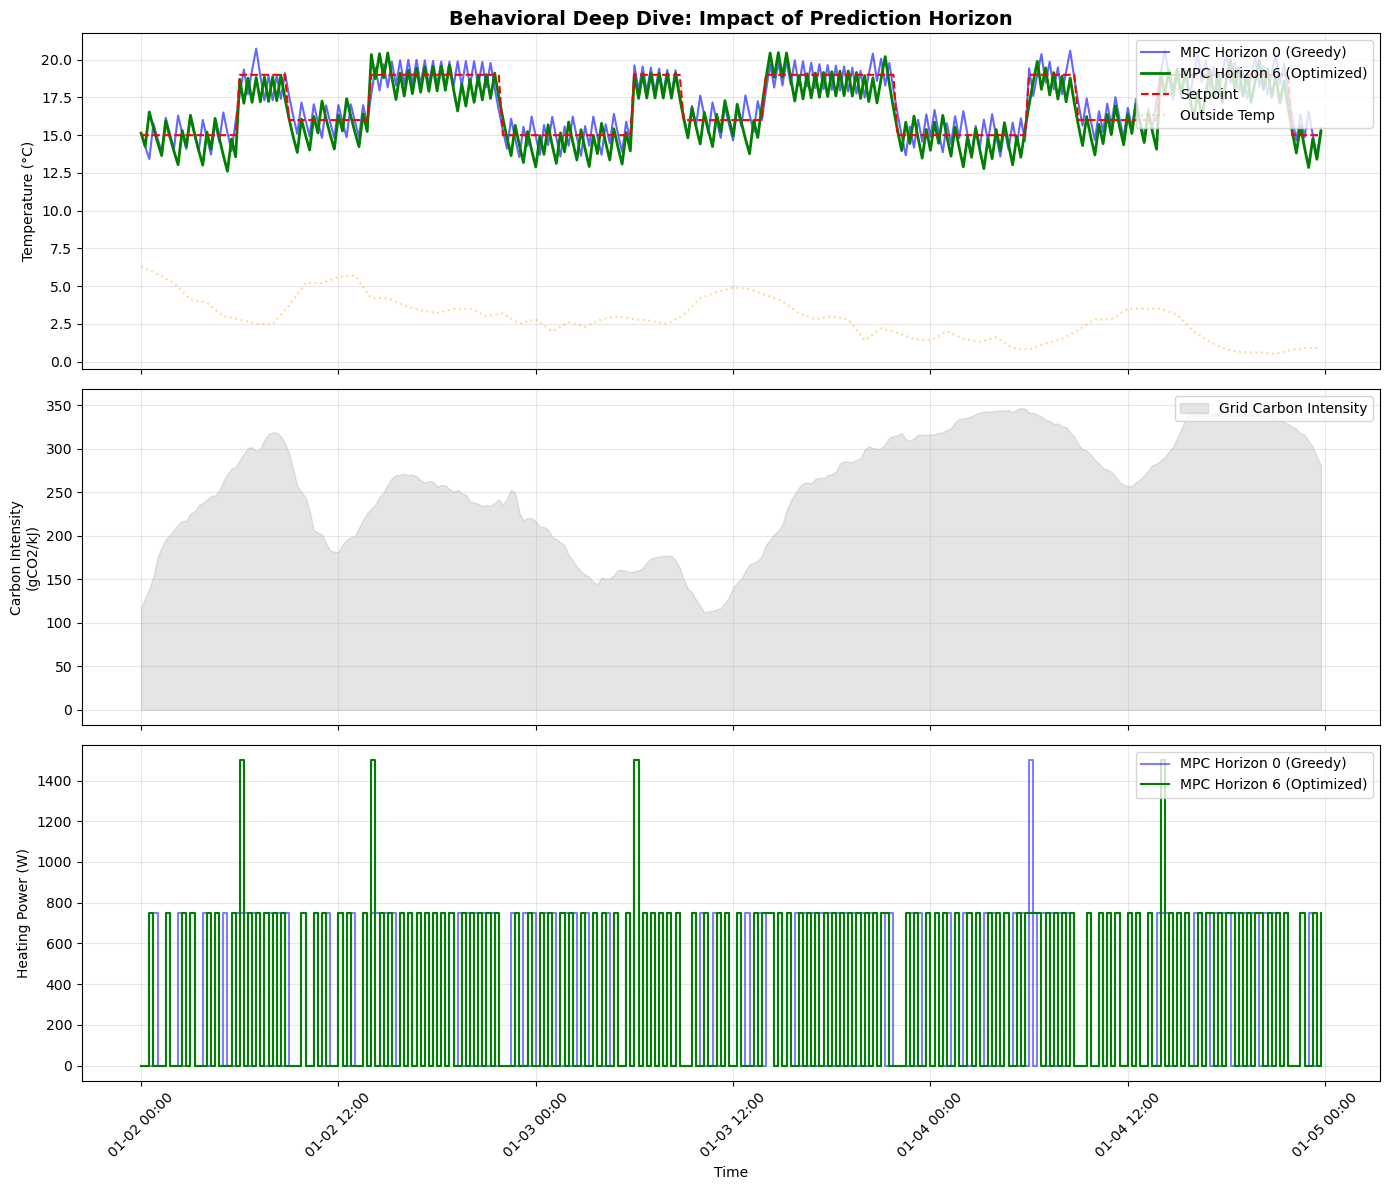

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# --- CONFIGURATION ---
DATA_DIR = r"D:\SSE\carbon aware thermostat"

def create_behavioral_plot(file1_name, file2_name, label1, label2, title, output_filename):
    """
    Loads two simulation files and creates a 3-panel comparison plot:
    1. Temperature tracking
    2. Carbon Intensity
    3. Heating Power
    """
    path1 = os.path.join(DATA_DIR, file1_name)
    path2 = os.path.join(DATA_DIR, file2_name)
    
    if not (os.path.exists(path1) and os.path.exists(path2)):
        print(f"Skipping plot: One or both files not found ({file1_name}, {file2_name})")
        return

    # Load data
    df1 = pd.read_csv(path1)
    df2 = pd.read_csv(path2)
    
    # Convert timestamps
    df1['timestamp'] = pd.to_datetime(df1['timestamp'])
    df2['timestamp'] = pd.to_datetime(df2['timestamp'])
    
    # Select a 3-day window to see behavior clearly (adjust dates as needed)
    start_date = '2025-01-02'
    end_date = '2025-01-05'
    
    d1 = df1[(df1['timestamp'] >= start_date) & (df1['timestamp'] < end_date)]
    d2 = df2[(df2['timestamp'] >= start_date) & (df2['timestamp'] < end_date)]
    
    # Create the figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # --- Panel 1: Temperature ---
    ax1.plot(d1['timestamp'], d1['room_temprature'], label=label1, color='blue', alpha=0.6)
    ax1.plot(d2['timestamp'], d2['room_temprature'], label=label2, color='green', linewidth=2)
    ax1.plot(d1['timestamp'], d1['preferred_room_temperature_C'], label='Setpoint', color='red', linestyle='--')
    ax1.plot(d1['timestamp'], d1['outside_temperature_C'], label='Outside Temp', color='orange', alpha=0.4, linestyle=':')
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', frameon=True)
    ax1.grid(True, alpha=0.3)
    
    # --- Panel 2: Carbon Intensity ---
    ax2.fill_between(d1['timestamp'], d1['carbon_intensity_gco2_per_kj'], color='gray', alpha=0.2, label='Grid Carbon Intensity')
    ax2.set_ylabel("Carbon Intensity\n(gCO2/kJ)")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # --- Panel 3: Heating Power ---
    ax3.step(d1['timestamp'], d1['heating_wattage_W'], label=label1, where='post', color='blue', alpha=0.5)
    ax3.step(d2['timestamp'], d2['heating_wattage_W'], label=label2, where='post', color='green', linewidth=1.5)
    ax3.set_ylabel("Heating Power (W)")
    ax3.set_xlabel("Time")
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    
    # Format X-axis dates
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    
    # Save the plot back to the same directory
    save_path = os.path.join(DATA_DIR, output_filename)
    plt.savefig(save_path, dpi=300)
    print(f"Success: Saved plot to {save_path}")
    plt.show()

# --- EXECUTION ---

# Comparison 1: Bang-Bang vs Carbon-Aware MPC
create_behavioral_plot(
    file1_name='room_data_bang_c.csv', 
    file2_name='room_data_mpc_c_6.csv', 
    label1='Bang-Bang (Reactive)', 
    label2='MPC Horizon 6 (Carbon-Aware)', 
    title='Behavioral Deep Dive: Bang-Bang vs. Carbon-Aware MPC', 
    output_filename='deep_dive_bang_vs_mpc.png'
)

# Comparison 2: Greedy (H=0) vs Optimized (H=6)
create_behavioral_plot(
    file1_name='room_data_mpc_c_0.csv', 
    file2_name='room_data_mpc_c_6.csv', 
    label1='MPC Horizon 0 (Greedy)', 
    label2='MPC Horizon 6 (Optimized)', 
    title='Behavioral Deep Dive: Impact of Prediction Horizon', 
    output_filename='deep_dive_horizon_impact.png'
)

Loading and processing data...
Analysis complete. Plots saved to: D:\SSE\carbon aware thermostat


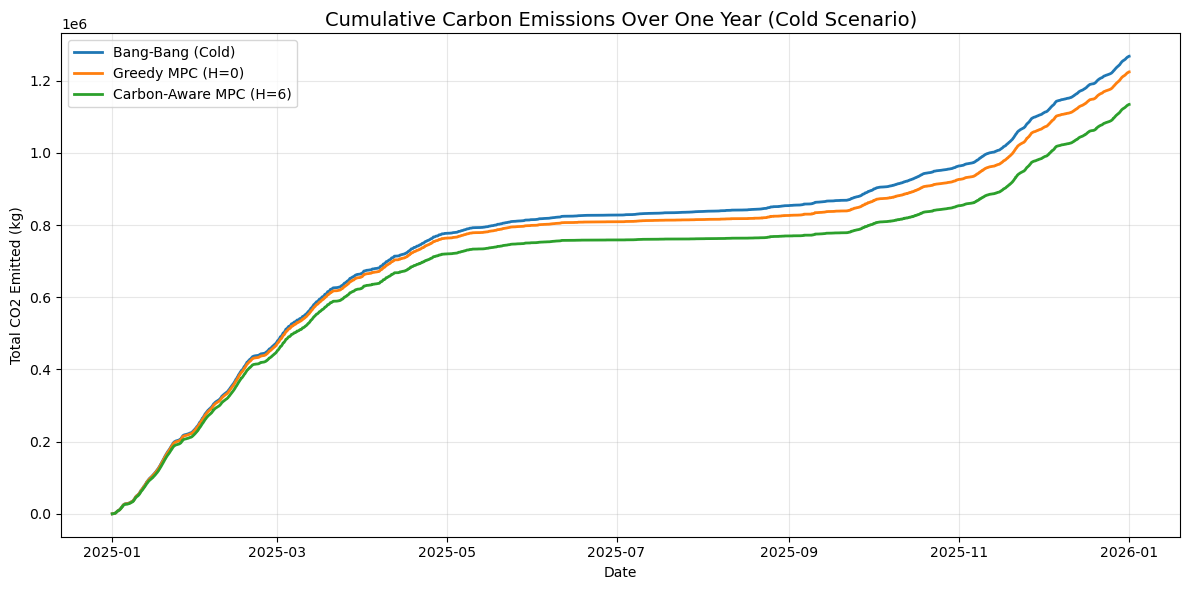

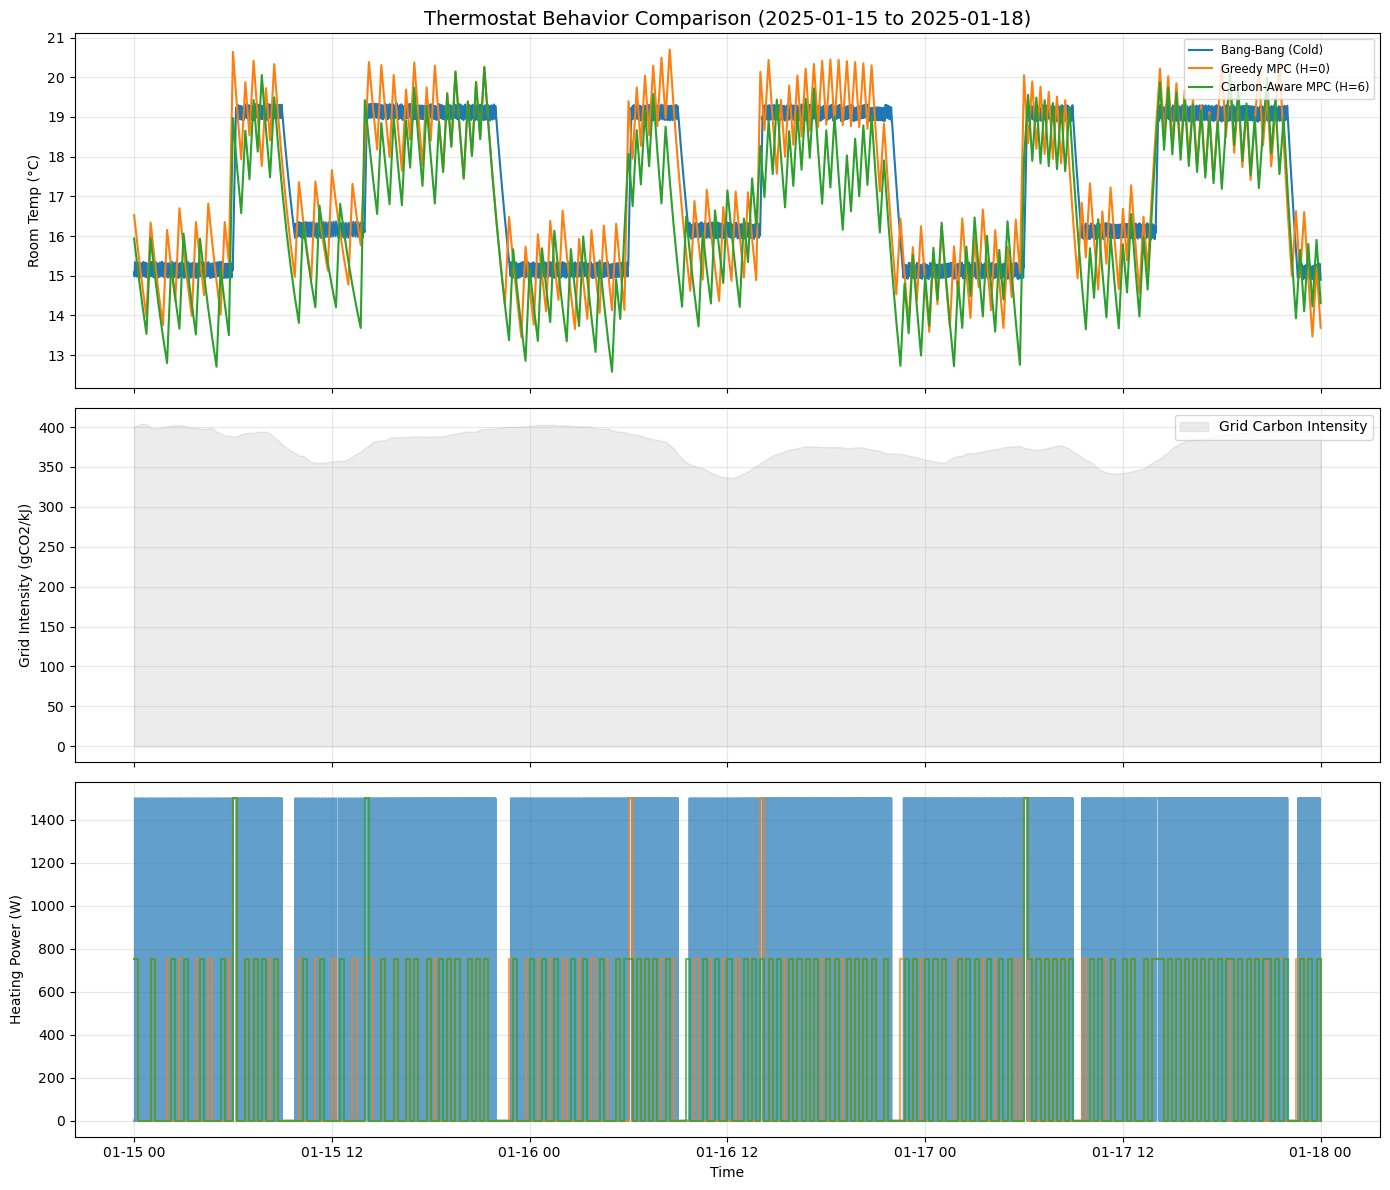

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
DATA_DIR = r"D:\SSE\carbon aware thermostat"

# Mapping the "Cold" files for comparison
target_files = {
    "Bang-Bang (Cold)": "room_data_bang_c.csv",
    "Greedy MPC (H=0)": "room_data_mpc_c_0.csv",
    "Carbon-Aware MPC (H=6)": "room_data_mpc_c_6.csv"
}

data_dict = {}

print("Loading and processing data...")
for label, filename in target_files.items():
    file_path = os.path.join(DATA_DIR, filename)
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
        # --- ENERGY & CARBON CALCULATIONS ---
        # Energy (kJ) = (Watts * seconds) / 1000
        df['energy_kj'] = (df['heating_wattage_W'] * df['dt']) / 1000
        # CO2 (g) = Energy (kJ) * Carbon Intensity (gCO2/kJ)
        df['co2_g'] = df['energy_kj'] * df['carbon_intensity_gco2_per_kj']
        df['cum_co2_kg'] = df['co2_g'].cumsum() / 1000
        
        data_dict[label] = df
    else:
        print(f"Warning: {filename} not found in {DATA_DIR}")

if not data_dict:
    print("No files were found. Please check your DATA_DIR.")
else:
    # --- PLOT 1: CUMULATIVE CO2 (The Whole Year) ---
    plt.figure(figsize=(12, 6))
    for label, df in data_dict.items():
        plt.plot(df['timestamp'], df['cum_co2_kg'], label=label, linewidth=2)
    
    plt.title("Cumulative Carbon Emissions Over One Year (Cold Scenario)", fontsize=14)
    plt.ylabel("Total CO2 Emitted (kg)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "cumulative_co2_analysis.png"))

    # --- PLOT 2: BEHAVIORAL DEEP DIVE (Winter Snapshot) ---
    start_zoom, end_zoom = "2025-01-15", "2025-01-18"
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    colors = {"Bang-Bang (Cold)": "#1f77b4", "Greedy MPC (H=0)": "#ff7f0e", "Carbon-Aware MPC (H=6)": "#2ca02c"}

    for label, df in data_dict.items():
        mask = (df['timestamp'] >= start_zoom) & (df['timestamp'] <= end_zoom)
        sub = df[mask]
        
        ax1.plot(sub['timestamp'], sub['room_temprature'], label=label, color=colors[label], linewidth=1.5)
        ax3.step(sub['timestamp'], sub['heating_wattage_W'], label=label, color=colors[label], where='post', alpha=0.7)

    ax1.set_ylabel("Room Temp (°C)")
    ax1.set_title(f"Thermostat Behavior Comparison ({start_zoom} to {end_zoom})", fontsize=14)
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(True, alpha=0.3)

    # Grid Carbon Intensity Plot (Shared background)
    ref_label = list(data_dict.keys())[0]
    ref_df = data_dict[ref_label]
    ref_mask = (ref_df['timestamp'] >= start_zoom) & (ref_df['timestamp'] <= end_zoom)
    ax2.fill_between(ref_df.loc[ref_mask, 'timestamp'], ref_df.loc[ref_mask, 'carbon_intensity_gco2_per_kj'], 
                     color='gray', alpha=0.15, label='Grid Carbon Intensity')
    ax2.set_ylabel("Grid Intensity (gCO2/kJ)")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    ax3.set_ylabel("Heating Power (W)")
    ax3.set_xlabel("Time")
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "behavioral_timeseries_analysis.png"))
    print(f"Analysis complete. Plots saved to: {DATA_DIR}")

In [15]:
import pandas as pd
import numpy as np
import os

# --- CONFIGURATION ---
DATA_DIR = r"D:\SSE\carbon aware thermostat"

def run_load_shifting_audit(base_path):
    # Comparing the three main controllers in the Cold scenario
    target_files = {
        "Bang-Bang (Cold)": "room_data_bang_c.csv",
        "Greedy MPC (H=0)": "room_data_mpc_c_0.csv",
        "Carbon-Aware MPC (H=6)": "room_data_mpc_c_6.csv"
    }
    
    audit_results = []

    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            
            # Determine window size (1 hour)
            avg_dt = df['dt'].mean()
            window_size = int(3600 / avg_dt) 
            
            # 1. Carbon Correlation (r)
            rolled_wattage = df['heating_wattage_W'].rolling(window=window_size).mean()
            rolled_intensity = df['carbon_intensity_gco2_per_kj'].rolling(window=window_size).mean()
            corr = rolled_wattage.corr(rolled_intensity)
            
            # 2. Low Carbon Ratio
            median_intensity = df['carbon_intensity_gco2_per_kj'].median()
            low_carbon_energy = df[df['carbon_intensity_gco2_per_kj'] <= median_intensity]['heating_wattage_W'].sum()
            total_energy = df['heating_wattage_W'].sum()
            low_carbon_ratio = (low_carbon_energy / total_energy) * 100

            audit_results.append({
                "Controller": label,
                "Carbon_Correlation (r)": round(corr, 4),
                "Low_Carbon_Heating_%": f"{round(low_carbon_ratio, 1)}%"
            })
            
    # Save and Print
    audit_df = pd.DataFrame(audit_results)
    print("\n--- LOAD SHIFTING EFFICIENCY REPORT ---")
    print(audit_df.to_string(index=False))
    audit_df.to_csv(os.path.join(base_path, "load_shifting_audit.csv"), index=False)

# Execute
run_load_shifting_audit(DATA_DIR)


--- LOAD SHIFTING EFFICIENCY REPORT ---
            Controller  Carbon_Correlation (r) Low_Carbon_Heating_%
      Bang-Bang (Cold)                  0.3860                34.3%
      Greedy MPC (H=0)                  0.3556                33.5%
Carbon-Aware MPC (H=6)                  0.3216                34.9%


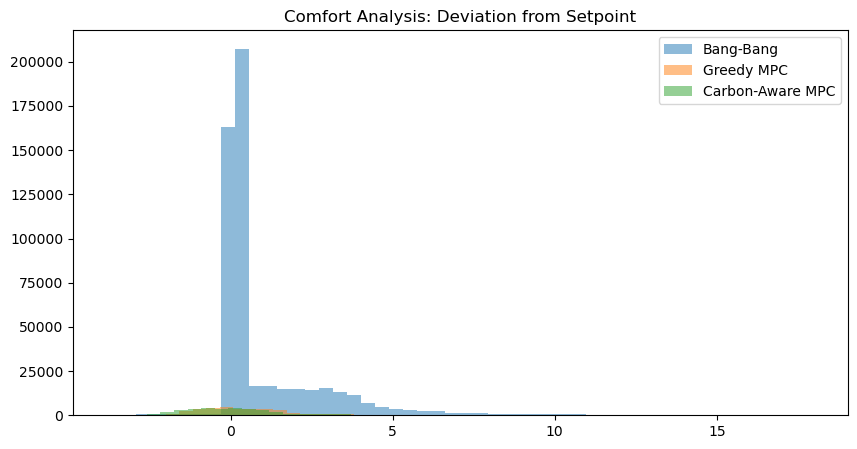

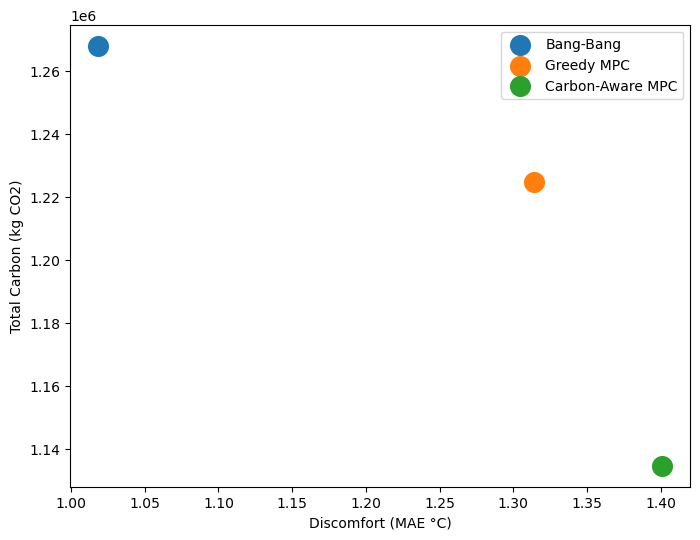

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = r"D:\SSE\carbon aware thermostat"
files = {"Bang-Bang": "room_data_bang_c.csv", "Greedy MPC": "room_data_mpc_c_0.csv", "Carbon-Aware MPC": "room_data_mpc_c_6.csv"}

# 1. Load Data
data = {label: pd.read_csv(os.path.join(DATA_DIR, f)) for label, f in files.items()}

# 2. Comfort Histogram
plt.figure(figsize=(10, 5))
for label, df in data.items():
    error = df['room_temprature'] - df['preferred_room_temperature_C']
    plt.hist(error, bins=50, alpha=0.5, label=label)
plt.title("Comfort Analysis: Deviation from Setpoint")
plt.legend()
plt.savefig(os.path.join(DATA_DIR, "comfort_tracking_histogram.png"))

# 3. Trade-off Scatter Plot
plt.figure(figsize=(8, 6))
for label, df in data.items():
    mae = (df['room_temprature'] - df['preferred_room_temperature_C']).abs().mean()
    total_co2 = (df['heating_wattage_W'] * df['dt'] / 1000 * df['carbon_intensity_gco2_per_kj']).sum() / 1000
    plt.scatter(mae, total_co2, s=200, label=label)
plt.xlabel("Discomfort (MAE °C)")
plt.ylabel("Total Carbon (kg CO2)")
plt.legend()
plt.savefig(os.path.join(DATA_DIR, "comfort_efficiency_tradeoff.png"))

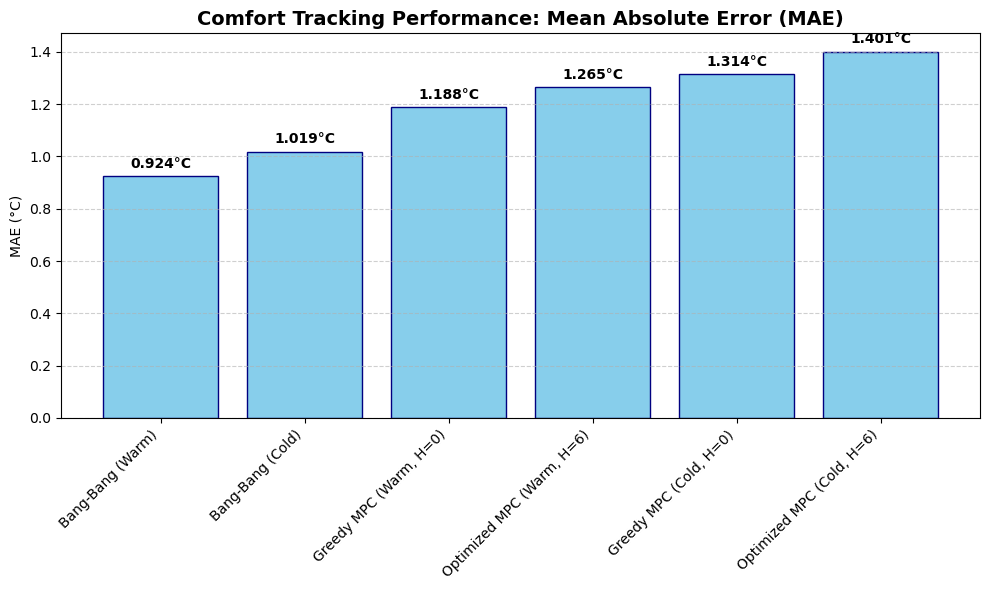

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your summary data
df = pd.read_csv(r"D:\SSE\carbon aware thermostat\final_analysis_summary.csv")

# Mapping filenames to descriptive labels for the report
name_map = {
    "room_data_bang_c.csv": "Bang-Bang (Cold)",
    "room_data_mpc_c_0.csv": "Greedy MPC (Cold, H=0)",
    "room_data_mpc_c_6.csv": "Optimized MPC (Cold, H=6)",
    "room_data_bang_w.csv": "Bang-Bang (Warm)",
    "room_data_mpc_w_0.csv": "Greedy MPC (Warm, H=0)",
    "room_data_mpc_w_6.csv": "Optimized MPC (Warm, H=6)"
}
df['Controller'] = df['File'].map(name_map)

# Sort by MAE (Lower is better comfort tracking)
df_sorted = df.sort_values('MAE_degC', ascending=True)

# Generate the Bar Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(df_sorted['Controller'], df_sorted['MAE_degC'], color='skyblue', edgecolor='navy')

plt.title("Comfort Tracking Performance: Mean Absolute Error (MAE)", fontsize=14, fontweight='bold')
plt.ylabel("MAE (°C)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding the exact MAE value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}°C", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(r"D:\SSE\carbon aware thermostat\mae_comparison_bar_chart.png")
plt.show()

Processing Cold Scenario...


C:\Users\prana\AppData\Local\Temp\ipykernel_25528\1161008095.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Controller', y='temp_error', data=full_df, palette="muted", inner="quartile")


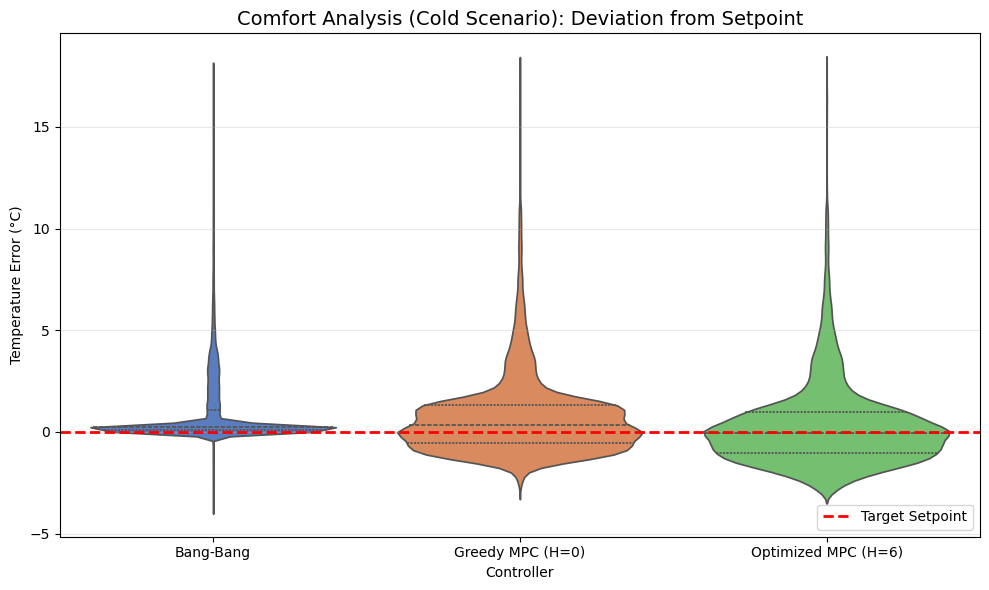

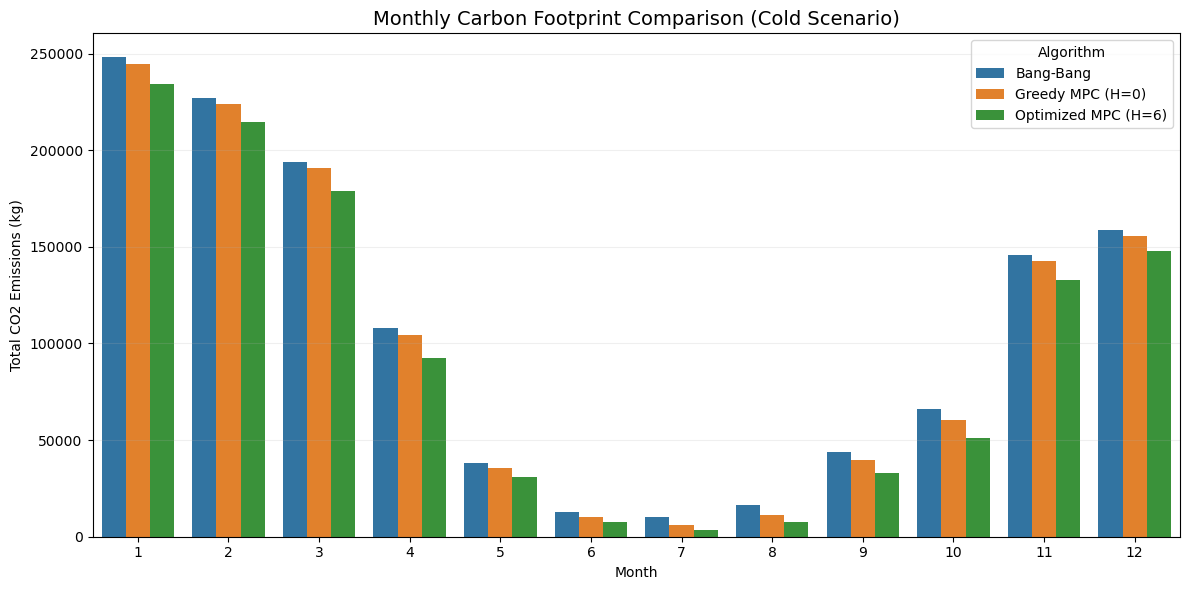

Processing Warm Scenario...


C:\Users\prana\AppData\Local\Temp\ipykernel_25528\1161008095.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Controller', y='temp_error', data=full_df, palette="muted", inner="quartile")


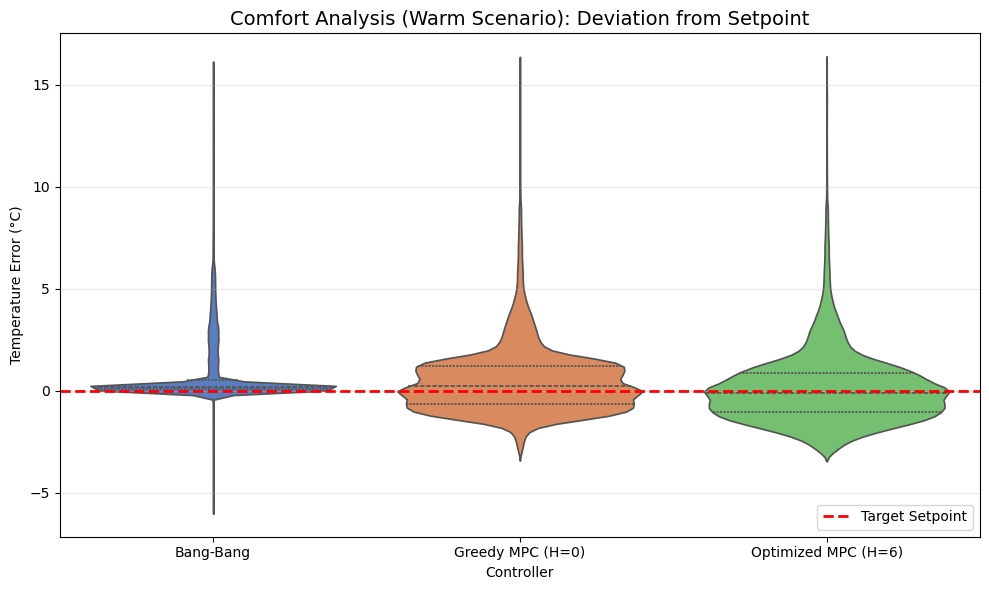

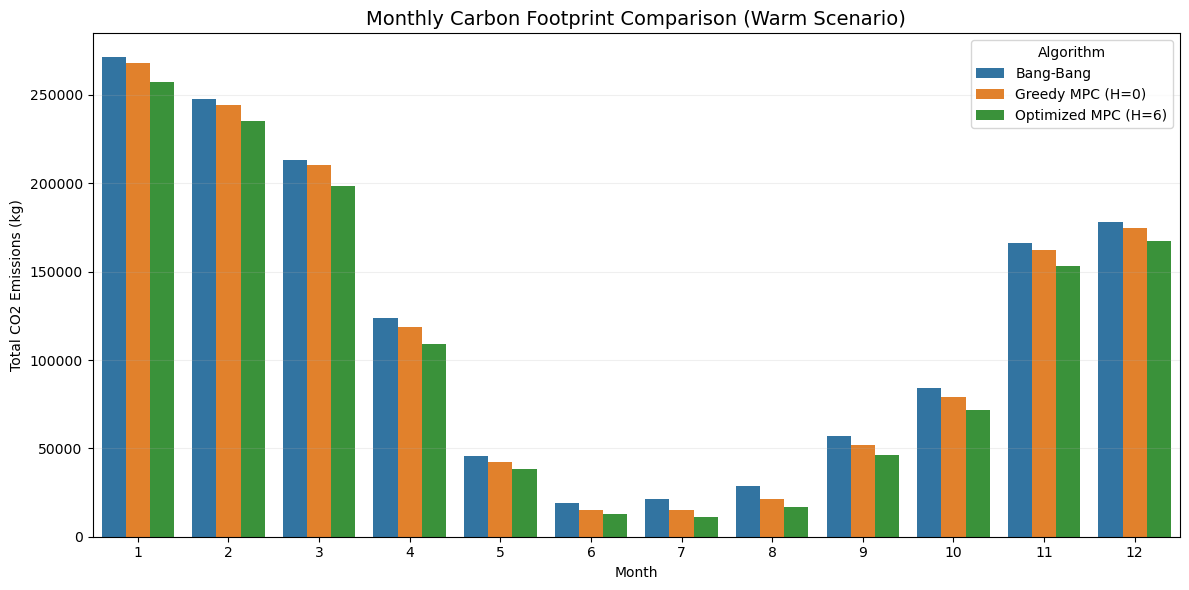

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. SETUP ---
# Update this path to your local folder
DATA_DIR = r"D:\SSE\carbon aware thermostat"

def process_and_plot(scenario_name, file_dict, suffix):
    """Loads data, calculates metrics, and generates two key plots per scenario."""
    all_data = []
    
    print(f"Processing {scenario_name}...")
    
    for label, filename in file_dict.items():
        file_path = os.path.join(DATA_DIR, filename)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df['Month'] = df['timestamp'].dt.month
            df['Controller'] = label
            
            # Carbon Calculation (kg CO2)
            # Energy (kJ) = (Watts * seconds) / 1000
            # Carbon (kg) = (kJ * intensity_g/kJ) / 1000
            df['co2_kg'] = ((df['heating_wattage_W'] * df['dt']) / 1000 * df['carbon_intensity_gco2_per_kj']) / 1000
            
            # Temperature Deviation from Setpoint
            df['temp_error'] = df['room_temprature'] - df['preferred_room_temperature_C']
            
            all_data.append(df)

    if not all_data:
        print(f"Error: No files found for {scenario_name}")
        return

    full_df = pd.concat(all_data)

    # --- PLOT 1: TEMPERATURE DEVIATION (Violin Plot) ---
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Controller', y='temp_error', data=full_df, palette="muted", inner="quartile")
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Target Setpoint')
    plt.title(f"Comfort Analysis ({scenario_name}): Deviation from Setpoint", fontsize=14)
    plt.ylabel("Temperature Error (°C)")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"temp_violin_{suffix}.png"))
    plt.show()

    # --- PLOT 2: MONTHLY CARBON FOOTPRINT (Bar Chart) ---
    monthly_agg = full_df.groupby(['Month', 'Controller'])['co2_kg'].sum().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Month', y='co2_kg', hue='Controller', data=monthly_agg)
    plt.title(f"Monthly Carbon Footprint Comparison ({scenario_name})", fontsize=14)
    plt.ylabel("Total CO2 Emissions (kg)")
    plt.xlabel("Month")
    plt.grid(axis='y', alpha=0.2)
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"monthly_carbon_{suffix}.png"))
    plt.show()

# --- 2. DEFINE THE DATASETS ---
cold_scenario = {
    "Bang-Bang": "room_data_bang_c.csv",
    "Greedy MPC (H=0)": "room_data_mpc_c_0.csv",
    "Optimized MPC (H=6)": "room_data_mpc_c_6.csv"
}

warm_scenario = {
    "Bang-Bang": "room_data_bang_w.csv",
    "Greedy MPC (H=0)": "room_data_mpc_w_0.csv",
    "Optimized MPC (H=6)": "room_data_mpc_w_6.csv"
}

# --- 3. RUN ANALYSIS ---
process_and_plot("Cold Scenario", cold_scenario, "cold")
process_and_plot("Warm Scenario", warm_scenario, "warm")